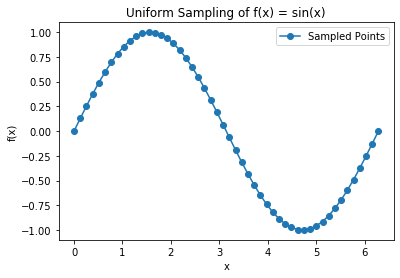

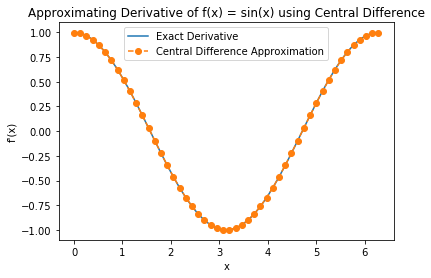

In [11]:
import numpy as np
import matplotlib.pyplot as plt
# Define the function and the domain
f = lambda x: np.sin(x)
a, b = 0, 2 * np.pi # Interval
N = 50 # Number of sample points
# Create a uniform grid
x = np.linspace(a, b, N)
y = f(x)
# Plot the sampled points
plt.plot(x, y, 'o-', label='Sampled Points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Uniform Sampling of f(x) = sin(x)')
plt.legend()
plt.show()

# Step size
h = (b - a) / (N - 1)
# Central Difference Approximation for the derivative
df_dx = (f(x + h) - f(x - h)) / (2 * h)
# Plot the approximation and the true derivative
plt.plot(x, np.cos(x), label='Exact Derivative')
plt.plot(x, df_dx, 'o--', label='Central Difference Approximation')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title("Approximating Derivative of f(x) = sin(x) using Central Difference")
plt.legend()
plt.show()

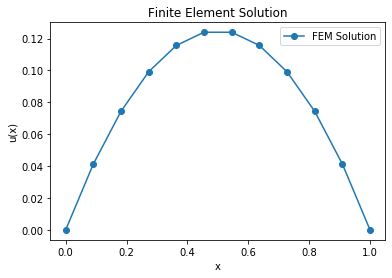

In [8]:
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# Problem setup
L = 1  # Length of the domain
N = 10  # Number of elements
h = L / (N + 1)  # Element size

# Source term
f = np.ones(N)

# Assemble the system matrix
diagonals = [[-2] * N, [1] * (N - 1), [1] * (N - 1)]
A = diags(diagonals, [0, -1, 1]) / h**2

# Solve for u in Au = -f
u = spsolve(A, -f)

# Add boundary values (Dirichlet condition u(0) = u(1) = 0)
u = np.concatenate(([0], u, [0]))

# Plot the solution
x = np.linspace(0, L, N + 2)
plt.plot(x, u, 'o-', label='FEM Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Finite Element Solution')
plt.legend()
plt.show()

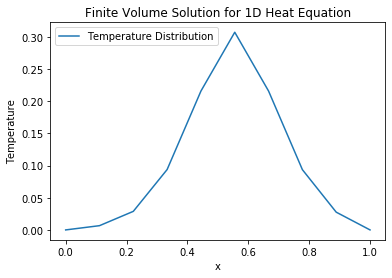

In [3]:
# Parameters
alpha = 0.01  # Diffusion coefficient
dx = 0.1
dt = 0.01
L = 1.0
Nx = int(L / dx)
u = np.zeros(Nx)  # Initial temperature distribution
u[int(Nx/2)] = 1.0  # Initial heat at the center

# FVM discretization loop
for n in range(100):
    u_new = u.copy()
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new

# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation')
plt.legend()
plt.show()

In [4]:
from scipy.fft import fft, ifft


# Sample the function on a periodic domain
N = 64
x = np.linspace(0, 2 * np.pi, N, endpoint=False)
f = np.sin(x)

# Compute Fourier transform and reconstruct
f_hat = fft(f)
f_reconstructed = ifft(f_hat).real

# Plot the original and reconstructed function
plt.plot(x, f, label='Original Function')
plt.plot(x, f_reconstructed, '--', label='Reconstructed (Spectral)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Fourier Spectral Approximation of f(x) = sin(x)')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'scipy.fft'

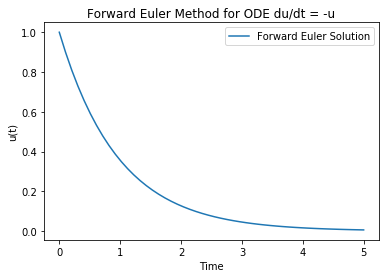

In [14]:
# Define parameters
T = 5.0 # Final time
dt = 0.1 # Time step
N = int(T / dt)
u = np.zeros(N)
u[0] = 1 # Initial condition
# Time-stepping loop
for n in range(1, N):
    u[n] = u[n-1] - dt * u[n-1]
# Plot the solution
t = np.linspace(0, T, N)
plt.plot(t, u, label='Forward Euler Solution')
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.title('Forward Euler Method for ODE du/dt = -u')
plt.legend()
plt.show()